# Base Agents Training - Technical & Sentiment

**Objective:** Train two specialized base agents for portfolio optimization:

1. **Technical Agent**: Specializes in price patterns, momentum, and volume analysis (20 features)
2. **Sentiment Agent**: Specializes in market psychology and crowd behavior (12 features)

**Training Strategy:**
- Algorithm: PPO (Proximal Policy Optimization)
- Reward: EMA Sharpe Ratio (balances returns and risk)
- Early Stopping: Based on validation performance
- Evaluation: Comprehensive metrics on train/val/test sets

**Expected Results:**
- Technical Agent: Strong trend-following, momentum capture
- Sentiment Agent: Regime shifts, psychology-driven moves

## Setup & Imports

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import helper modules
from helpers import (
    # Config
    BaseAgentConfig,
    TICKERS,
    MODELS_DIR,
    AGENT_MODELS_DIR,
    
    # Training
    train_base_agent,
    evaluate_agent,
    plot_training_history,
    plot_agent_performance,
    
    # Utils
    print_metrics,
    save_agent_results
)

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Imports complete")
print(f"   Tickers: {TICKERS}")
print(f"   Models directory: {MODELS_DIR}")

✅ Imports complete
   Tickers: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
   Models directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Verify Data Availability

In [2]:
from helpers import DATA_DIR, load_metadata

# Check data files exist
required_files = [
    DATA_DIR / 'technical' / 'train.csv',
    DATA_DIR / 'technical' / 'val.csv',
    DATA_DIR / 'technical' / 'test.csv',
    DATA_DIR / 'sentiment' / 'train.csv',
    DATA_DIR / 'sentiment' / 'val.csv',
    DATA_DIR / 'sentiment' / 'test.csv',
    DATA_DIR / 'returns_train.csv',
    DATA_DIR / 'returns_val.csv',
    DATA_DIR / 'returns_test.csv',
    DATA_DIR / 'metadata.json'
]

print("Checking data files...")
all_exist = True
for file in required_files:
    if file.exists():
        print(f"  ✅ {file.name}")
    else:
        print(f"  ❌ {file.name} NOT FOUND")
        all_exist = False

if not all_exist:
    raise FileNotFoundError("Missing data files! Please run 01_data_prep.ipynb first.")

# Load and display metadata
metadata = load_metadata()
print("\n📊 Data Summary:")
print(f"   Stocks: {', '.join(metadata['tickers'])}")
print(f"   Date Range: {metadata['date_range']['start']} to {metadata['date_range']['end']}")
print(f"   Total Weeks: {metadata['date_range']['total_weeks']}")
print(f"   Train: {metadata['splits']['train']['weeks']} weeks")
print(f"   Val: {metadata['splits']['val']['weeks']} weeks")
print(f"   Test: {metadata['splits']['test']['weeks']} weeks")
print(f"   Technical Features: {metadata['features']['technical']['count']}")
print(f"   Sentiment Features: {metadata['features']['sentiment']['count']}")

Checking data files...
  ✅ train.csv
  ✅ val.csv
  ✅ test.csv
  ✅ train.csv
  ✅ val.csv
  ✅ test.csv
  ✅ returns_train.csv
  ✅ returns_val.csv
  ✅ returns_test.csv
  ✅ metadata.json

📊 Data Summary:
   Stocks: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
   Date Range: 2020-01-03 to 2025-11-07
   Total Weeks: 306
   Train: 183 weeks
   Val: 61 weeks
   Test: 62 weeks
   Technical Features: 20
   Sentiment Features: 12


---
## Part 1: Train Technical Agent

**Technical Agent Specialization:**
- **Trend Following**: SMAs, EMAs (identify trends)
- **Momentum**: MACD, RSI, Stochastic (timing entries)
- **Volatility**: ATR, Bollinger Bands (risk management)
- **Volume**: Volume ratios, MFI, OBV (confirm moves)
- **Benchmark**: Correlation & beta (market relationship)

**Reward Function:** EMA Sharpe Ratio
- Online learning: No lookback window needed
- Balances returns and risk automatically
- Smooth gradients for RL optimization

### 1.1 Configure Training Parameters

In [3]:
# Display default configuration
print("Base Agent Training Configuration:")
print("="*60)
config_dict = BaseAgentConfig.to_dict()
for key, value in config_dict.items():
    print(f"  {key:20s}: {value}")
print("="*60)

# You can modify these if needed
# For example, for faster testing:
# BaseAgentConfig.TOTAL_TIMESTEPS = 50000
# BaseAgentConfig.EVAL_FREQ = 5000

Base Agent Training Configuration:
  learning_rate       : 0.0003
  n_steps             : 2048
  batch_size          : 64
  n_epochs            : 10
  gamma               : 0.99
  gae_lambda          : 0.95
  clip_range          : 0.2
  ent_coef            : 0.01
  vf_coef             : 0.5
  max_grad_norm       : 0.5
  total_timesteps     : 200000
  net_arch            : [256, 256]
  activation          : tanh
  eval_freq           : 10000
  n_eval_episodes     : 10
  patience            : 5
  min_delta           : 0.01


### 1.2 Train Technical Agent

In [4]:
print("\n" + "="*70)
print("TRAINING TECHNICAL AGENT")
print("="*70)

# Train the agent
tech_model, tech_history = train_base_agent(
    agent_type='technical',
    agent_name='technical_ema_sharpe',
    reward_type='ema_sharpe',
    config=BaseAgentConfig,
    save_model=True,
    verbose=0
)

print("\n✅ Technical Agent training complete!")
print(f"   Model saved to: {AGENT_MODELS_DIR / 'technical_ema_sharpe.zip'}")
print(f"   Training time: {tech_history['training_time']:.1f} seconds")
print(f"   Best validation reward: {tech_history['best_reward']:.4f}")
print(f"   Early stopped: {tech_history['early_stopped']}")


TRAINING TECHNICAL AGENT


Output()


✅ Technical Agent training complete!
   Model saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/agent_models/technical_ema_sharpe.zip
   Training time: 22.0 seconds
   Best validation reward: 58.9710
   Early stopped: True


### 1.3 Visualize Technical Agent Training

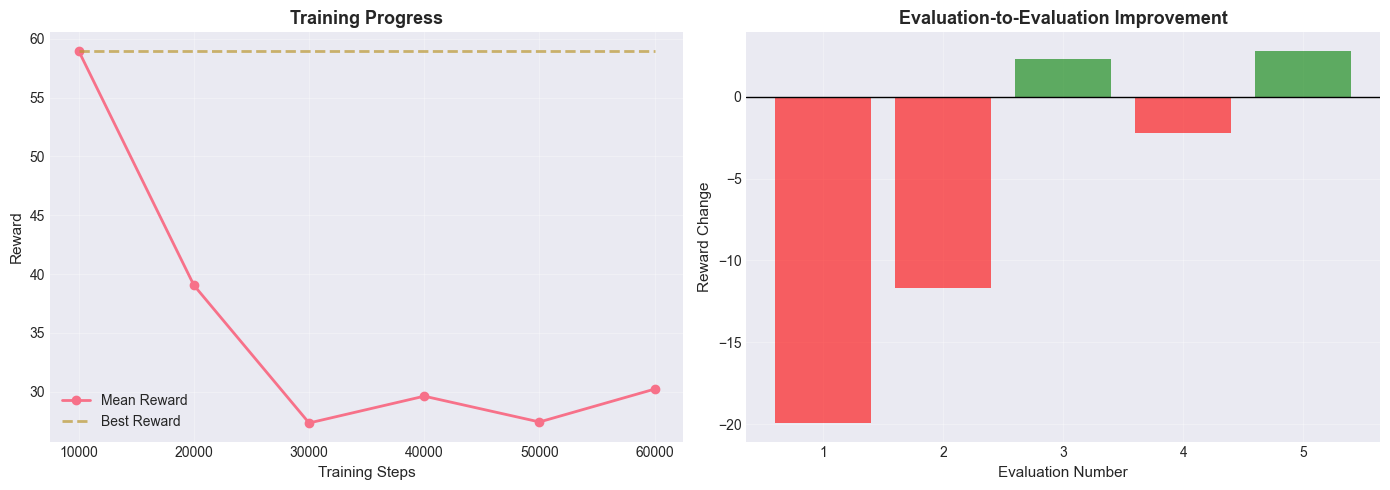

In [5]:
# Plot training history
plot_training_history(tech_history)

### 1.4 Evaluate Technical Agent

In [6]:
print("\n" + "="*70)
print("EVALUATING TECHNICAL AGENT")
print("="*70)

# Evaluate on all splits
tech_train_results = evaluate_agent(tech_model, 'technical', split='train', verbose=1)
tech_val_results = evaluate_agent(tech_model, 'technical', split='val', verbose=1)
tech_test_results = evaluate_agent(tech_model, 'technical', split='test', verbose=1)

# Summary comparison
print("\n" + "="*70)
print("TECHNICAL AGENT - PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Metric':<20s} {'Train':>12s} {'Val':>12s} {'Test':>12s}")
print("-"*70)

metrics_to_compare = ['annual_return', 'annual_volatility', 'sharpe_ratio', 
                       'sortino_ratio', 'max_drawdown', 'win_rate']

for metric in metrics_to_compare:
    train_val = tech_train_results['metrics'][metric]
    val_val = tech_val_results['metrics'][metric]
    test_val = tech_test_results['metrics'][metric]
    
    if 'ratio' in metric or metric == 'win_rate':
        print(f"{metric:<20s} {train_val:>12.2f} {val_val:>12.2f} {test_val:>12.2f}")
    else:
        print(f"{metric:<20s} {train_val*100:>11.2f}% {val_val*100:>11.2f}% {test_val*100:>11.2f}%")

print("="*70)


EVALUATING TECHNICAL AGENT

EVALUATING AGENT ON TRAIN SET

TRAIN Set Performance
Total Return:        3396.41%
Annual Return:        108.05%
Annual Volatility:     35.26%
Sharpe Ratio:           2.95
Sortino Ratio:          6.20
Max Drawdown:         -27.86%
Calmar Ratio:           3.88
Win Rate:              66.12%
N Periods:               183


EVALUATING AGENT ON VAL SET

VAL Set Performance
Total Return:          34.14%
Annual Return:         30.95%
Annual Volatility:     34.06%
Sharpe Ratio:           0.79
Sortino Ratio:          1.10
Max Drawdown:         -24.52%
Calmar Ratio:           1.26
Win Rate:              57.38%
N Periods:                61


EVALUATING AGENT ON TEST SET

TEST Set Performance
Total Return:         127.62%
Annual Return:         77.68%
Annual Volatility:     42.11%
Sharpe Ratio:           1.75
Sortino Ratio:          3.49
Max Drawdown:         -27.10%
Calmar Ratio:           2.87
Win Rate:              64.52%
N Periods:                62


TECHNICAL AGEN

### 1.5 Visualize Technical Agent Performance

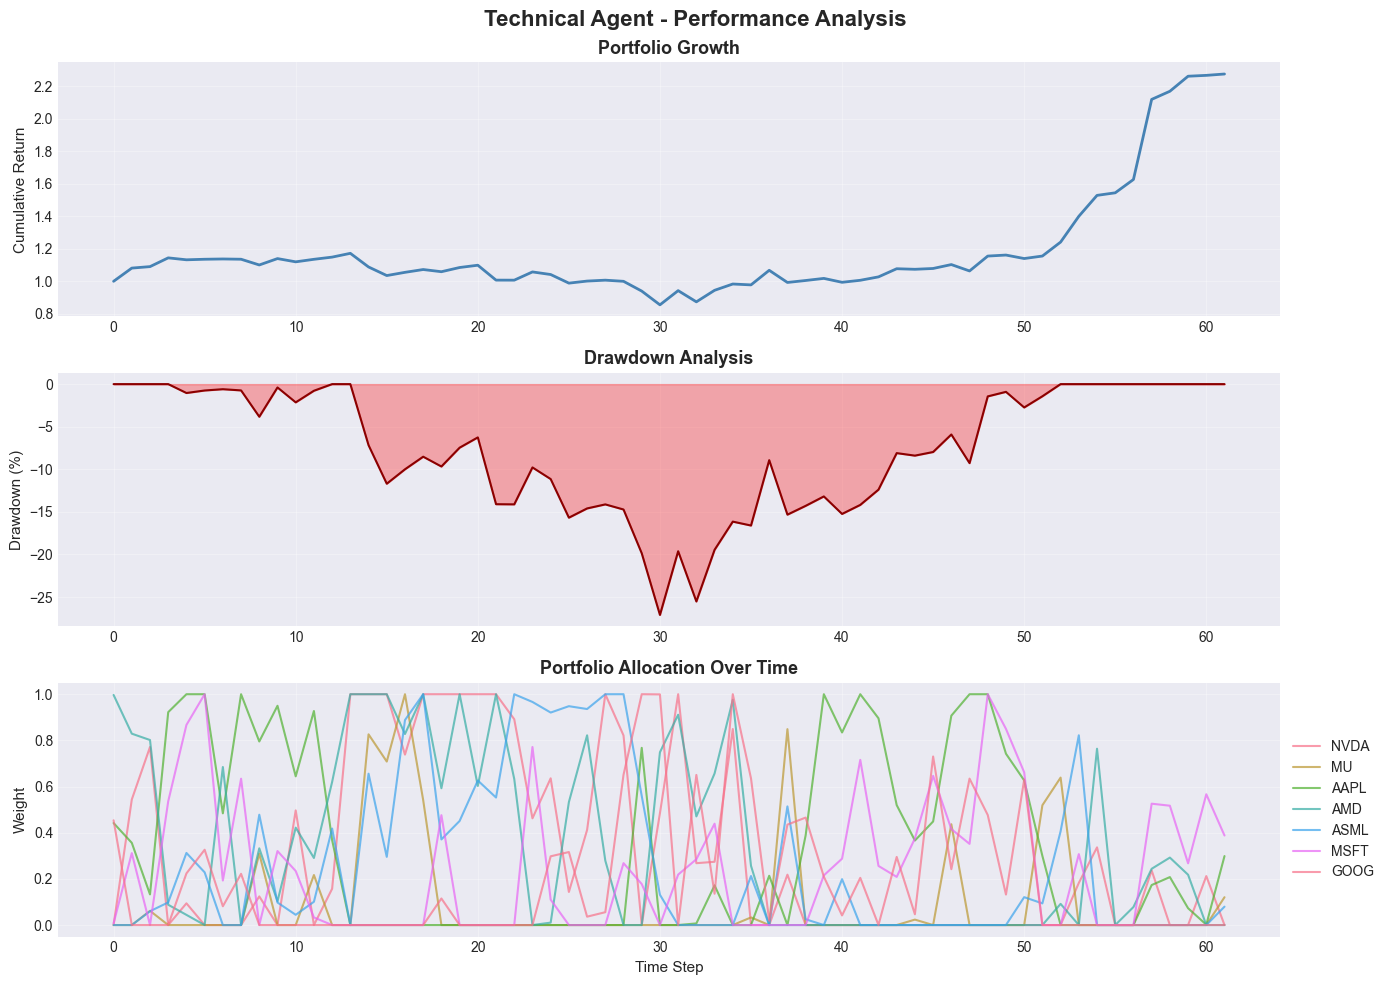

In [7]:
# Plot test set performance
plot_agent_performance(tech_test_results, 'Technical Agent')

### 1.6 Save Technical Agent Results

In [8]:
# Compile all results
tech_complete_results = {
    'agent_type': 'technical',
    'agent_name': 'technical_ema_sharpe',
    'reward_type': 'ema_sharpe',
    'training_history': tech_history,
    'performance': {
        'train': tech_train_results['metrics'],
        'val': tech_val_results['metrics'],
        'test': tech_test_results['metrics']
    }
}

# Save results
save_agent_results('technical_ema_sharpe', tech_complete_results)

print("✅ Technical Agent results saved")

✅ Results saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/technical_ema_sharpe_results.json
✅ Technical Agent results saved


---
## Part 2: Train Sentiment Agent

**Sentiment Agent Specialization:**
- **Momentum Signals**: Multi-timeframe momentum (2W, 4W, 6W)
- **Trend Quality**: Win rate, cross-sectional dispersion
- **Volume Sentiment**: Volume-weighted returns, surge detection
- **Market Regime**: Volatility regime, drawdowns
- **Fear/Greed**: Volatility spikes, credit spreads (proxies)

**Key Difference from Technical:**
- Focuses on **psychology** rather than patterns
- Detects **regime shifts** and crowd behavior
- Complements technical signals

### 2.1 Train Sentiment Agent

In [9]:
print("\n" + "="*70)
print("TRAINING SENTIMENT AGENT")
print("="*70)

# Train the agent
sent_model, sent_history = train_base_agent(
    agent_type='sentiment',
    agent_name='sentiment_ema_sharpe',
    reward_type='ema_sharpe',
    config=BaseAgentConfig,
    save_model=True,
    verbose=0
)

print("\n✅ Sentiment Agent training complete!")
print(f"   Model saved to: {AGENT_MODELS_DIR / 'sentiment_ema_sharpe.zip'}")
print(f"   Training time: {sent_history['training_time']:.1f} seconds")
print(f"   Best validation reward: {sent_history['best_reward']:.4f}")
print(f"   Early stopped: {sent_history['early_stopped']}")


TRAINING SENTIMENT AGENT


Output()


✅ Sentiment Agent training complete!
   Model saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/agent_models/sentiment_ema_sharpe.zip
   Training time: 20.3 seconds
   Best validation reward: 20.9284
   Early stopped: True


### 2.2 Visualize Sentiment Agent Training

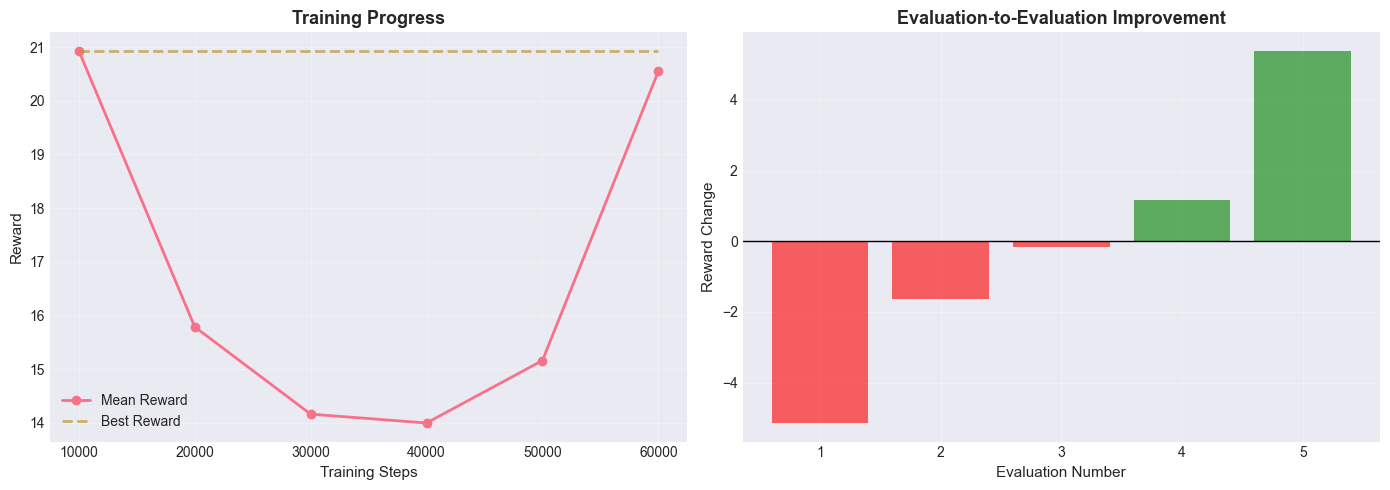

In [10]:
# Plot training history
plot_training_history(sent_history)

### 2.3 Evaluate Sentiment Agent

In [11]:
print("\n" + "="*70)
print("EVALUATING SENTIMENT AGENT")
print("="*70)

# Evaluate on all splits
sent_train_results = evaluate_agent(sent_model, 'sentiment', split='train', verbose=1)
sent_val_results = evaluate_agent(sent_model, 'sentiment', split='val', verbose=1)
sent_test_results = evaluate_agent(sent_model, 'sentiment', split='test', verbose=1)

# Summary comparison
print("\n" + "="*70)
print("SENTIMENT AGENT - PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Metric':<20s} {'Train':>12s} {'Val':>12s} {'Test':>12s}")
print("-"*70)

for metric in metrics_to_compare:
    train_val = sent_train_results['metrics'][metric]
    val_val = sent_val_results['metrics'][metric]
    test_val = sent_test_results['metrics'][metric]
    
    if 'ratio' in metric or metric == 'win_rate':
        print(f"{metric:<20s} {train_val:>12.2f} {val_val:>12.2f} {test_val:>12.2f}")
    else:
        print(f"{metric:<20s} {train_val*100:>11.2f}% {val_val*100:>11.2f}% {test_val*100:>11.2f}%")

print("="*70)


EVALUATING SENTIMENT AGENT

EVALUATING AGENT ON TRAIN SET

TRAIN Set Performance
Total Return:        3009.54%
Annual Return:        105.36%
Annual Volatility:     37.34%
Sharpe Ratio:           2.71
Sortino Ratio:          5.41
Max Drawdown:         -28.12%
Calmar Ratio:           3.75
Win Rate:              66.67%
N Periods:               183


EVALUATING AGENT ON VAL SET

VAL Set Performance
Total Return:          34.47%
Annual Return:         29.44%
Annual Volatility:     28.88%
Sharpe Ratio:           0.88
Sortino Ratio:          1.58
Max Drawdown:         -18.84%
Calmar Ratio:           1.56
Win Rate:              55.74%
N Periods:                61


EVALUATING AGENT ON TEST SET

TEST Set Performance
Total Return:         -15.60%
Annual Return:        -24.32%
Annual Volatility:     28.58%
Sharpe Ratio:          -0.99
Sortino Ratio:         -1.57
Max Drawdown:         -31.40%
Calmar Ratio:          -0.77
Win Rate:              38.71%
N Periods:                31


SENTIMENT AGEN

### 2.4 Visualize Sentiment Agent Performance

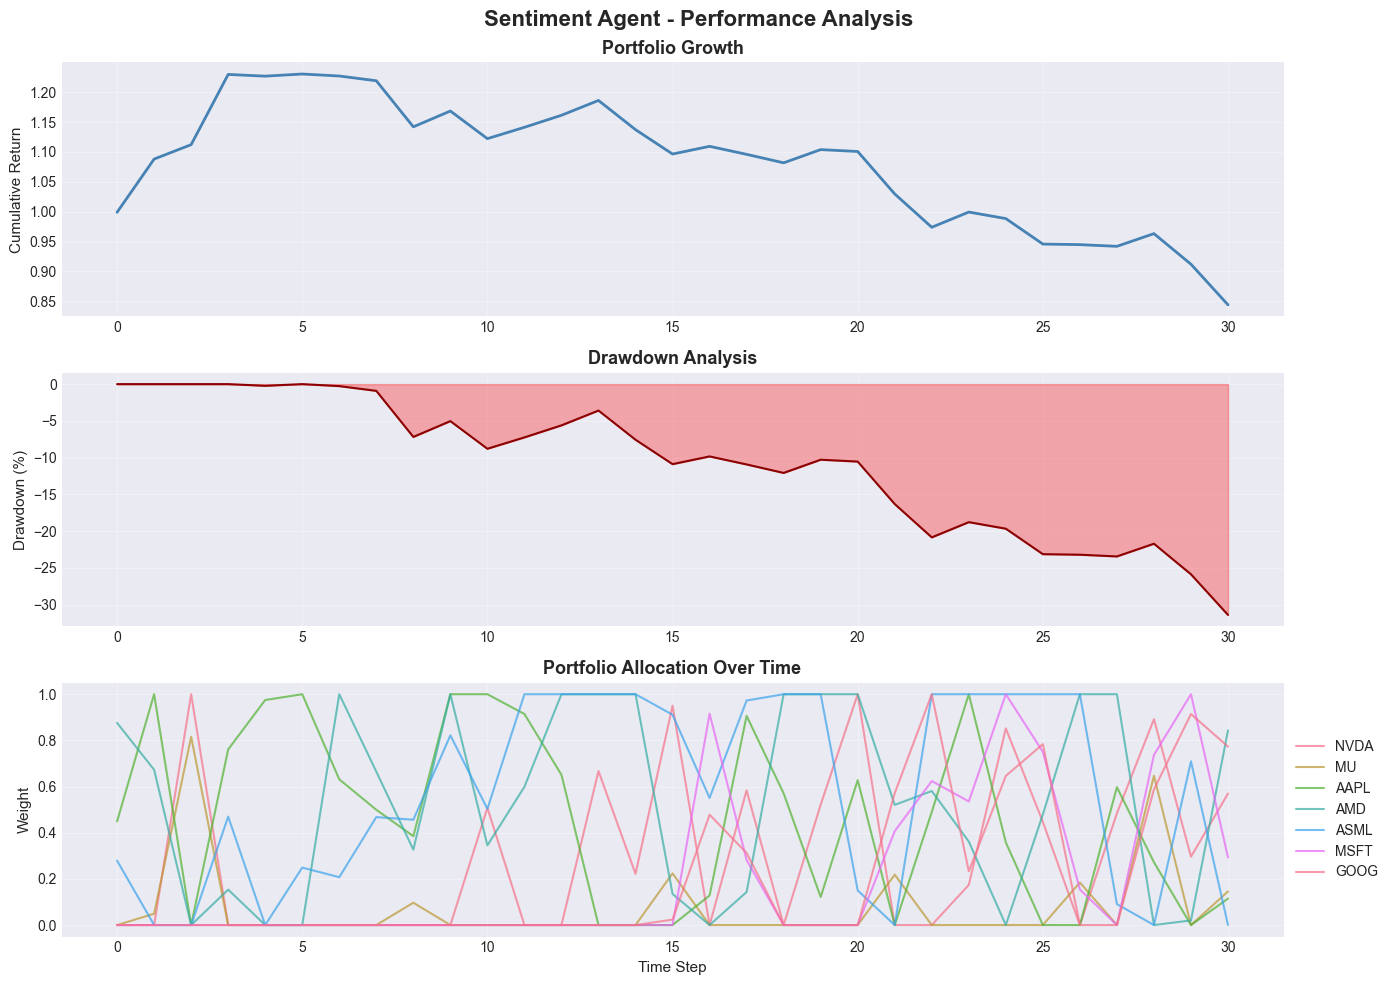

In [12]:
# Plot test set performance
plot_agent_performance(sent_test_results, 'Sentiment Agent')

### 2.5 Save Sentiment Agent Results

In [13]:
# Compile all results
sent_complete_results = {
    'agent_type': 'sentiment',
    'agent_name': 'sentiment_ema_sharpe',
    'reward_type': 'ema_sharpe',
    'training_history': sent_history,
    'performance': {
        'train': sent_train_results['metrics'],
        'val': sent_val_results['metrics'],
        'test': sent_test_results['metrics']
    }
}

# Save results
save_agent_results('sentiment_ema_sharpe', sent_complete_results)

print("✅ Sentiment Agent results saved")

✅ Results saved to /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/sentiment_ema_sharpe_results.json
✅ Sentiment Agent results saved


---
## Part 3: Compare Base Agents

**Analysis Questions:**
1. Which agent has higher Sharpe ratio?
2. Which agent has lower drawdowns?
3. Do they have complementary strengths?
4. What's the correlation of their returns?

### 3.1 Side-by-Side Comparison

In [14]:
# Compare on test set
print("\n" + "="*70)
print("BASE AGENTS COMPARISON - TEST SET")
print("="*70)
print(f"{'Metric':<20s} {'Technical':>15s} {'Sentiment':>15s} {'Difference':>15s}")
print("-"*70)

for metric in metrics_to_compare:
    tech_val = tech_test_results['metrics'][metric]
    sent_val = sent_test_results['metrics'][metric]
    diff = tech_val - sent_val
    
    if 'ratio' in metric or metric == 'win_rate':
        print(f"{metric:<20s} {tech_val:>15.2f} {sent_val:>15.2f} {diff:>+15.2f}")
    else:
        print(f"{metric:<20s} {tech_val*100:>14.2f}% {sent_val*100:>14.2f}% {diff*100:>+14.2f}%")

print("="*70)

# Calculate correlation
tech_returns = np.array(tech_test_results['returns'])
sent_returns = np.array(sent_test_results['returns'])
correlation = np.corrcoef(tech_returns, sent_returns)[0, 1]

print(f"\n📊 Returns Correlation: {correlation:.3f}")
if abs(correlation) < 0.5:
    print("   ✅ Low correlation - agents have complementary strategies!")
elif abs(correlation) < 0.8:
    print("   ⚠️  Moderate correlation - some overlap in strategies")
else:
    print("   ❌ High correlation - agents are very similar")


BASE AGENTS COMPARISON - TEST SET
Metric                     Technical       Sentiment      Difference
----------------------------------------------------------------------
annual_return                 77.68%         -24.32%        +102.00%
annual_volatility             42.11%          28.58%         +13.53%
sharpe_ratio                    1.75           -0.99           +2.74
sortino_ratio                   3.49           -1.57           +5.06
max_drawdown                 -27.10%         -31.40%          +4.31%
win_rate                        0.65            0.39           +0.26


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 62 and the array at index 1 has size 31

### 3.2 Visual Comparison

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Base Agents Comparison - Test Set', fontsize=16, fontweight='bold')

# Plot 1: Cumulative returns
ax = axes[0, 0]
tech_cum = (1 + tech_returns).cumprod()
sent_cum = (1 + sent_returns).cumprod()
ax.plot(tech_cum, label='Technical', linewidth=2, alpha=0.8)
ax.plot(sent_cum, label='Sentiment', linewidth=2, alpha=0.8)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Cumulative Return')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Drawdowns
ax = axes[0, 1]
tech_dd = (tech_cum - np.maximum.accumulate(tech_cum)) / np.maximum.accumulate(tech_cum)
sent_dd = (sent_cum - np.maximum.accumulate(sent_cum)) / np.maximum.accumulate(sent_cum)
ax.fill_between(range(len(tech_dd)), tech_dd * 100, 0, alpha=0.3, label='Technical')
ax.fill_between(range(len(sent_dd)), sent_dd * 100, 0, alpha=0.3, label='Sentiment')
ax.set_title('Drawdowns', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Returns distribution
ax = axes[1, 0]
ax.hist(tech_returns * 100, bins=30, alpha=0.5, label='Technical', color='steelblue')
ax.hist(sent_returns * 100, bins=30, alpha=0.5, label='Sentiment', color='orange')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Returns Distribution', fontweight='bold')
ax.set_xlabel('Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Scatter plot (correlation)
ax = axes[1, 1]
ax.scatter(tech_returns * 100, sent_returns * 100, alpha=0.6, s=50)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title(f'Returns Correlation (ρ={correlation:.2f})', fontweight='bold')
ax.set_xlabel('Technical Return (%)')
ax.set_ylabel('Sentiment Return (%)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Comparison visualizations complete")

ValueError: x and y must be the same size

---
## Summary & Next Steps

### Achievements
✅ Technical Agent trained and evaluated  
✅ Sentiment Agent trained and evaluated  
✅ Both models saved for Super Agent training  
✅ Performance metrics calculated  
✅ Complementarity analyzed  

### Key Insights
- Review the correlation: Low correlation = good diversification
- Check Sharpe ratios: Both should be >1.0 ideally
- Analyze drawdowns: Lower is better for risk management

### Next Steps
1. **Proceed to 03_super_agent.ipynb** to train the Super Agent
2. Super Agent will learn to blend these two specialists
3. Expected improvement: 10-20% over individual agents

In [16]:
print("\n" + "="*70)
print("BASE AGENTS TRAINING COMPLETE")
print("="*70)
print("\n✅ Trained Models:")
print(f"   {AGENT_MODELS_DIR / 'technical_ema_sharpe.zip'}")
print(f"   {AGENT_MODELS_DIR / 'sentiment_ema_sharpe.zip'}")
print("\n✅ Saved Results:")
print(f"   {MODELS_DIR / 'technical_ema_sharpe_results.json'}")
print(f"   {MODELS_DIR / 'sentiment_ema_sharpe_results.json'}")
print("\n🚀 Ready for Super Agent training!")
print("   → Run notebook 03_super_agent.ipynb")
print("="*70)


BASE AGENTS TRAINING COMPLETE

✅ Trained Models:
   /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/agent_models/technical_ema_sharpe.zip
   /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/agent_models/sentiment_ema_sharpe.zip

✅ Saved Results:
   /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/technical_ema_sharpe_results.json
   /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks/../models/sentiment_ema_sharpe_results.json

🚀 Ready for Super Agent training!
   → Run notebook 03_super_agent.ipynb
